In [1]:
import requests
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

In [2]:
# URL for the NASA Exoplanet Archive API
url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

# SQL query to get all confirmed exoplanets
query = """
SELECT pl_name, hostname, pl_orbper, pl_orbpererr1, pl_orbpererr2, pl_orbsmax, pl_rade, pl_radeerr1, pl_radeerr2, pl_bmasse, pl_bmasseerr1, pl_bmasseerr2, pl_dens, pl_denserr1, pl_denserr2, pl_eqt, pl_eqterr1, pl_eqterr2, pl_orbeccen, pl_orbeccenerr1, pl_orbeccenerr2, pl_insol, pl_insolerr1, pl_insolerr2, st_spectype, st_teff, st_rad, st_mass, st_met, st_age, st_vsin, sy_dist
FROM pscomppars
"""

# Define the parameters for the API request
params = {
    "query": query,
    "format": "csv"
}

# Make the request
response = requests.get(url, params=params)

# Check for errors
response.raise_for_status()

# Convert the response content to a pandas DataFrame
df = pd.read_csv(StringIO(response.text))

# Save locally if needed
df.to_csv("./data/confirmed_exoplanets.csv", index=False)

In [3]:
print(f"Downloaded {len(df)} confirmed exoplanets.")

Downloaded 6147 confirmed exoplanets.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6147 entries, 0 to 6146
Data columns (total 32 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6147 non-null   object 
 1   hostname         6147 non-null   object 
 2   pl_orbper        5814 non-null   float64
 3   pl_orbpererr1    5322 non-null   float64
 4   pl_orbpererr2    5322 non-null   float64
 5   pl_orbsmax       5831 non-null   float64
 6   pl_rade          6097 non-null   float64
 7   pl_radeerr1      4216 non-null   float64
 8   pl_radeerr2      4216 non-null   float64
 9   pl_bmasse        6116 non-null   float64
 10  pl_bmasseerr1    2981 non-null   float64
 11  pl_bmasseerr2    2981 non-null   float64
 12  pl_dens          6009 non-null   float64
 13  pl_denserr1      1404 non-null   float64
 14  pl_denserr2      1404 non-null   float64
 15  pl_eqt           4585 non-null   float64
 16  pl_eqterr1       1803 non-null   float64
 17  pl_eqterr2    

In [5]:
def filter_param(df, column, threshold):
    err1_col = column + 'err1'
    err2_col = column + 'err2'
    
    valid = df[column] != 0

    err = (abs(df[err1_col].values) + abs(df[err2_col].values)) / 2
    rel_err = err / df[column]

    mask = (rel_err < threshold) & valid
    
    return df[mask]

def filter_2param(df, column1, threshold1, column2, threshold2):
    def get_mask(col, threshold):
        err1_col = col + 'err1'
        err2_col = col + 'err2'
        valid = df[col] != 0
        err = (abs(df[err1_col].values) + abs(df[err2_col].values)) / 2
        rel_err = err / df[col]
        # rel_err1 = df[err1_col] / df[col]
        # rel_err2 = df[err2_col] / df[col]
        return (rel_err < threshold) & valid

    mask1 = get_mask(column1, threshold1)
    mask2 = get_mask(column2, threshold2)

    return df[mask1 & mask2]

In [6]:
# toi 4438 has 9.5% relative error in mass and 4.0% in radius
# toi 442 has 2.6% relative error in mass and 2.1% in radius

In [7]:
# planets with equal or less error than toi-4438 in mass and radius
filter_2param(df, 'pl_bmasse', 0.096, 'pl_rade', 0.041).shape[0]

305

In [8]:
# planets with equal or less error than toi-442 in mass and radius
print(filter_2param(df, 'pl_bmasse', 0.030, 'pl_rade', 0.025).shape[0])
print(filter_2param(df, 'pl_bmasse', 0.027, 'pl_rade', 0.023).shape[0])
toi442_df = filter_2param(df, 'pl_bmasse', 0.027, 'pl_rade', 0.022)
rad_df = filter_param(df, 'pl_rade', 0.2)
mass_df = filter_param(df, 'pl_bmasse', 0.1)
rad_mass_df10 = filter_2param(df, 'pl_bmasse', 0.1, 'pl_rade', 0.1)
rad_mass_df20 = filter_2param(df, 'pl_bmasse', 0.2, 'pl_rade', 0.2)

17
10


In [9]:
#@|-----------------------------------------------------------------
#@|Boundaries of the Neptunian desert (Castro-González et al. 2024)
#@|-----------------------------------------------------------------
x_tw_low = np.linspace(-0.30, np.log10(2.97), 100)
x_tw_low = np.linspace(-0.30, 0.47, 100)
x_tw_up = np.linspace(0.120, np.log10(2.97), 100)
x_tw_up = np.linspace(0.120, 0.473, 100)

y_tw_up = -0.43 * x_tw_up + 1.14
y_tw_low = +0.55 * x_tw_low + 0.36

color_boundaries = 'black'       #Color of the computed boundaries  
style_boundaries = 'dashed'      #Style of the boundaries

toi4438_p = 7.446295
toi4438_r = (2.40, 0.09, -0.10)
toi4438_m = (4.11, 0.40, -0.38)
toi442_p = 4.052032
toi442_r = (4.25, 0.10, -0.08)
toi442_m = (28.38, 0.77, -0.73)

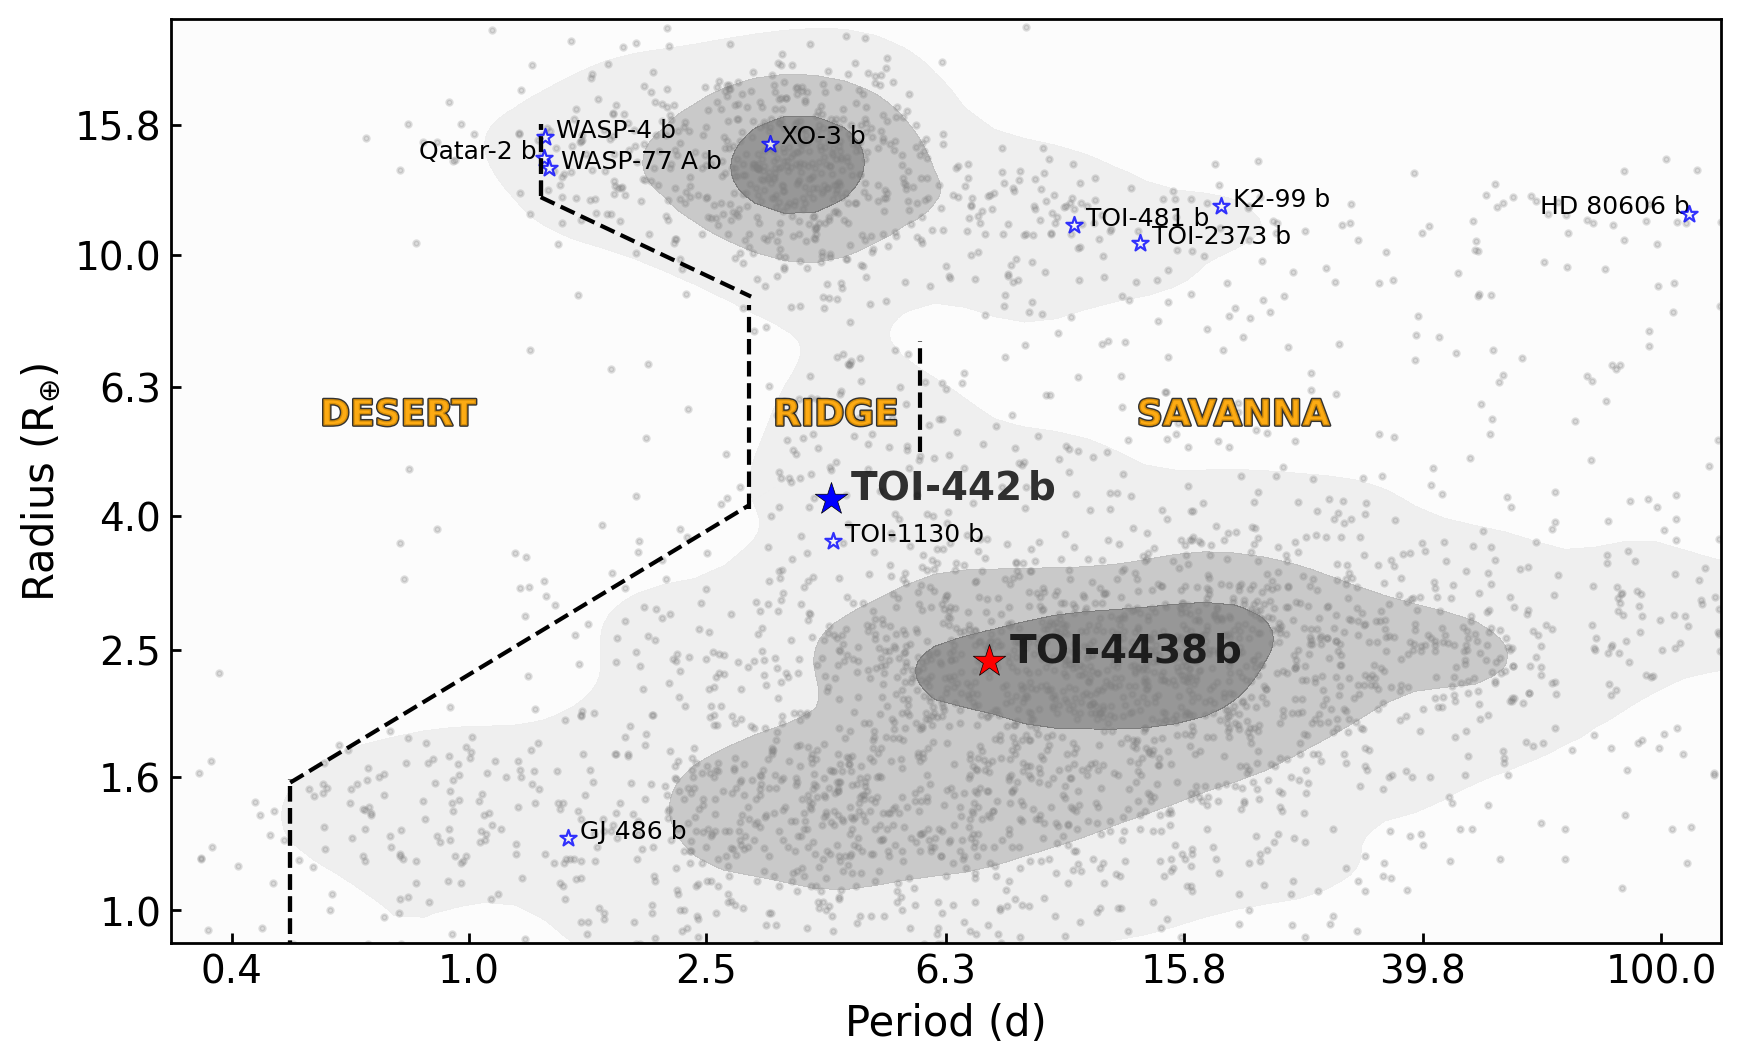

In [35]:
from matplotlib import patheffects as PathEffects
# plot them in period-radius space
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
# df_ = rad_mass_df20.copy()
df_ = rad_df.copy()
# precision planets
ax.scatter(np.log10(toi442_df['pl_orbper']), np.log10(toi442_df['pl_rade']), alpha=0.8, 
           marker='*', edgecolors='blue', c='white', s=38, linewidths=0.79, zorder=200)

fsize1 = 9
for i in range(len(toi442_df)):
    if toi442_df['pl_name'].values[i] in ['Qatar-2 b']:
        ax.text(np.log10(toi442_df['pl_orbper'].values[i])-0.21, np.log10(toi442_df['pl_rade'].values[i]),
                toi442_df['pl_name'].values[i], fontsize=fsize1, color='k', fontweight=100)
    elif toi442_df['pl_name'].values[i] in ['HD 80606 b']:
        ax.text(np.log10(toi442_df['pl_orbper'].values[i])-0.25, np.log10(toi442_df['pl_rade'].values[i]),
                toi442_df['pl_name'].values[i], fontsize=fsize1, color='k', fontweight=100)
    else:
        # how to scale text position based on period?
        ax.text(np.log10(toi442_df['pl_orbper'].values[i])+0.02, np.log10(toi442_df['pl_rade'].values[i]),
                toi442_df['pl_name'].values[i], fontsize=fsize1, color='k', fontweight=100)
        
# bulk of planets
ax.scatter(np.log10(df_['pl_orbper']), np.log10(df_['pl_rade']), s=4, alpha=0.25, 
           c='gray')
# TOI-4438 --------------------------------------
ax.scatter(np.log10(toi4438_p), np.log10(toi4438_r[0]), s=150, c='red', marker='*', edgecolors='k', linewidths=0.25)
up = np.log10(toi4438_r[0] + toi4438_r[1]) - np.log10(toi4438_r[0])
down = np.log10(toi4438_r[0]) - np.log10(toi4438_r[0] + toi4438_r[2])
# ax.errorbar(np.log10(toi4438_p), np.log10(toi4438_r[0]), 
#             yerr=[[down], [up]], 
#             xerr=[[0], [0]], fmt='o', color='k', 
#             label='TOI-4438 (mass)', capsize=3,
#             elinewidth=1, capthick=1)
# TOI-442 --------------------------------------
ax.scatter(np.log10(toi442_p), np.log10(toi442_r[0]), s=150, c='blue', marker='*', edgecolors='k', linewidths=0.25)
up = np.log10(toi442_r[0] + toi442_r[1]) - np.log10(toi442_r[0])
down = np.log10(toi442_r[0]) - np.log10(toi442_r[0] + toi442_r[2])
# ax.errorbar(np.log10(toi442_p), np.log10(toi442_r[0]), 
#             yerr=[[down], [up]], 
#             xerr=[[0], [0]], fmt='o', color='blue', markersize=1,
#             label='TOI-442 (mass)', capsize=1,
#             elinewidth=1, capthick=1)
#  Desert boundaries -------------------------------------
ax.plot(x_tw_up, y_tw_up,  c = color_boundaries, linestyle = style_boundaries, lw = 1.5, zorder = 1e1000)
ax.plot(x_tw_low, y_tw_low,  c = color_boundaries, linestyle = style_boundaries, lw = 1.5, zorder = 1e1000)
ax.vlines(x=[np.log10(2.95), -0.30, 0.12, np.log10(5.7)], ymin=[np.log10(4.1), -0.07, 1.09, np.log10(5)],\
           ymax=[np.log10(8.4), 0.20, 1.20, np.log10(7.4)], colors = color_boundaries, \
           linestyle = style_boundaries, lw = 1.5, zorder = 1e10000)
ax.vlines(x=[ -0.30, 0.12], ymin=[ -0.07, 1.09],\
           ymax=[0.20, 1.20], colors = color_boundaries, \
           linestyle = style_boundaries, lw = 1.5, zorder = 1e10000)
# Text annotations -------------------------------------
color_text = '#fea80a'
fsize = 13
txt=plt.text(-0.25, 0.74,'DESERT',zorder=100,fontsize=fsize,alpha=0.8,color=color_text,fontweight=600)
txt.set_path_effects([PathEffects.withStroke(linewidth=1, foreground='black')])
txt=plt.text(0.51, 0.74, 'RIDGE',zorder=100,fontsize=fsize,alpha=0.8,color=color_text,  fontweight = 600)
txt.set_path_effects([PathEffects.withStroke(linewidth=1, foreground='black')])
txt=plt.text(1.12, 0.74,'SAVANNA',zorder=100,fontsize=fsize,alpha=0.8,color=color_text, fontweight = 600)
txt.set_path_effects([PathEffects.withStroke(linewidth=1, foreground='black')])

txt=plt.text(np.log10(toi4438_p+0.6), np.log10(toi4438_r[0]),'TOI-4438$\,$b',zorder=100,fontsize=14,alpha=0.8,color='k',fontweight=600)
txt=plt.text(np.log10(toi442_p+0.3), np.log10(toi442_r[0]),'TOI-442$\,$b',zorder=100,fontsize=14,alpha=0.8,color='k',fontweight=600)
# Density contours -------------------------------------
sns.kdeplot(x=np.log10(rad_df['pl_orbper']), y=np.log10(rad_df['pl_rade']), cmap = 'Greys', \
            fill = True, zorder = -1, alpha = 0.5, bw_adjust= 0.5, \
            levels = [0,  0.16, 0.5, 0.84, 1.0])
ax.set_xlim(-0.5, 2.1)
ax.set_ylim(-0.05, 1.36)
# Change ytick labels to actual radius values
yticks = ax.get_yticks()
yticks = [np.log10(1.0), np.log10(1.6), np.log10(2.5), np.log10(4.0), np.log10(6.3), np.log10(10.0), np.log10(15.8)]
ytick_labels = [f"{10**ytick:.1f}" for ytick in yticks]
ax.set_yticks(yticks)
ax.set_yticklabels(ytick_labels, fontsize=14)
# Change xtick labels to actual period values
xticks = ax.get_xticks()
xticks = [np.log10(0.4), np.log10(1.0), np.log10(2.5), np.log10(6.3), np.log10(15.8), np.log10(39.8), np.log10(100.0)]
xtick_labels = [f"{10**xtick:.1f}" for xtick in xticks]
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels, fontsize=14)
# ---------------------------------------------------------------------------------
ax.set_xlabel('Period (d)', fontsize = 15)
ax.set_ylabel(r'Radius ($\rm R_{\oplus}$)', fontsize = 15)
ax.tick_params(which='major', length = 3.5, color = 'k', direction = 'in', width = 1.0)
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(1)
plt.savefig(f'./plots/paper/desert_plot.pdf', facecolor='w', bbox_inches='tight', format='pdf')
plt.show()

In [127]:
np.log10(20)

1.3010299956639813